**INTRODUCTION**
Motivation
In the modern financial landscape, the ability to accurately assess credit risk is a critical component of lending operations. Financial institutions strive to minimize default rates while maximizing the approval of viable loans. The primary objective of this project is to develop a predictive model that can classify loan applicants based on their likelihood of defaulting. By leveraging machine learning techniques, we aim to provide a data-driven approach to loan approval, helping to reduce financial risk and improve decision-making efficiency.

Dataset Description
This project utilizes the [Loan Approval Prediction,], obtained from [Kaggle/UCI Machine Learning Repository]. The dataset contains [58,645] observations and [ 20] variables. It captures diverse information regarding loan applicants, including demographic profiles, employment history, and specific loan details.

Key Variables and Target
The dataset consists of a mix of numerical and categorical variables, including:

Demographic/Personal Data: [e.g., Age, home ownership status, employment length].

Loan Details: [e.g., Loan amount, interest rate, loan intent, loan-to-income ratio].

The target variable loan_status is binary, where 0 indicates successful loan repayment and 1 indicates a loan default. A preliminary analysis of the target distribution reveals a class imbalance, with 0 representing ~85.8% of the data and 1 representing ~14.2%. This imbalance suggests that standard accuracy may be a misleading metric, and we will focus on performance measures like F1-score and ROC-AUC to ensure the model effectively identifies the minority class (defaulters).


**PROBLEM STATEMENT: **
Predicting whether a loan application will be approved is a binary classification problem. By identifying high-risk applicants, banks can minimize default rates.

IMPORTS

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Suppress TensorFlow logging: 0 = all, 1 = INFO, 2 = WARNING, 3 = ERROR
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # '2' suppresses INFO and WARNING messages
import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras import models, layers, Input

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


sns.set_style("whitegrid")

LOAD DATASET

In [76]:
import pandas as pd

# Load the training data (usually used to train your model)
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s4e10/train.csv")

# Load the test data (the data you need to predict on)
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s4e10/test.csv")

# Load the sample submission (to understand the required output format)
sample_sub = pd.read_csv("/kaggle/input/competitions/playground-series-s4e10/sample_submission.csv")

# Display the first few rows of the training set
train_df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


This project predicts whether a loan application will be approved.
This is a binary classification problem where the target variable is Loan_Status.

This is important for banks to reduce risk and automate decision-making.

**Feature Enginnering Function**

In [77]:
def engineer_features(df):
    df = df.copy()
    # Adding the "Secret Sauce" ratio
    df['loan_percent_income'] = df['loan_amnt'] / df['person_income']
    # Log transform skew
    df['loan_amnt_log'] = np.log1p(df['loan_amnt'])
    df['person_income_log'] = np.log1p(df['person_income'])
    return df

train_df = engineer_features(train_df)
test_df = engineer_features(test_df)

**Data cleaning**

"We first inspected the data for missing values and duplicates. We handled outliers in the income feature using  to ensure our models aren't biased by extreme values."

In [78]:
import pandas as pd

# 1. Encoding 'loan_grade' (Ordinal)
# We map these to numeric values to preserve the risk order (A is best, G is worst)
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
train_df['loan_grade'] = train_df['loan_grade'].map(grade_mapping)

# 2. Encoding 'cb_person_default_on_file' (Binary)
# Maps Y to 1 and N to 0
train_df['cb_person_default_on_file'] = train_df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

# 3. Encoding 'person_home_ownership' and 'loan_intent' (Nominal)
# Using one-hot encoding (get_dummies) for these since they have no set order
categorical_cols = ['person_home_ownership', 'loan_intent']
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)

# Check the new structure
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           58645 non-null  int64  
 1   person_age                   58645 non-null  int64  
 2   person_income                58645 non-null  int64  
 3   person_emp_length            58645 non-null  float64
 4   loan_grade                   58645 non-null  int64  
 5   loan_amnt                    58645 non-null  int64  
 6   loan_int_rate                58645 non-null  float64
 7   loan_percent_income          58645 non-null  float64
 8   cb_person_default_on_file    58645 non-null  int64  
 9   cb_person_cred_hist_length   58645 non-null  int64  
 10  loan_status                  58645 non-null  int64  
 11  loan_amnt_log                58645 non-null  float64
 12  person_income_log            58645 non-null  float64
 13  person_home_owne

**FEATURE ENGINEERING**

In [79]:
# --- 1. DEFINE X AND Y ---
# X should be your features (everything except the ID and the target)
X = train_df.drop(['id', 'loan_status'], axis=1)
y = train_df['loan_status']

# --- 2. CONVERT REMAINING TEXT TO NUMBERS ---
# Now that X is defined, this line will work
X_encoded = pd.get_dummies(X, drop_first=True)
test_encoded = pd.get_dummies(test_df.drop(['id'], axis=1), drop_first=True)

# Align the test set with the training set
X_final, test_final = X_encoded.align(test_encoded, join='inner', axis=1)

# --- 3. TRAIN THE MODEL ---
model = XGBClassifier(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42
)
model.fit(X_final, y)
print("Model trained successfully!")

Model trained successfully!


In [80]:
# Apply the log transformation
train_df["loan_amnt_log"] = np.log(train_df["loan_amnt"] + 1)
train_df["person_income_log"] = np.log(train_df["person_income"] + 1)
print("Transformation complete. Here is a preview:")
train_df[["loan_amnt", "loan_amnt_log", "person_income", "person_income_log"]].head()

Transformation complete. Here is a preview:


,loan_amnt,loan_amnt_log,person_income,person_income_log
0,6000,8.699681,35000,10.463132
1,4000,8.294300,56000,10.933125
2,6000,8.699681,28800,10.268165
3,12000,9.392745,70000,11.156265
4,6000,8.699681,60000,11.002117


**ENCODING**

In [81]:
# 1. You don't need to map 'loan_status' if it's already 0/1 integers
# You can verify this by printing the unique values:
print(train_df['loan_status'].unique())

# 2. Get dummies
# columns might already be converted to booleans. 
# You only need to run this if you have new categorical columns.
train_df = pd.get_dummies(train_df, drop_first=True)
# 1. Ensure your data is in 'train_df'
# Replace 'NAME_OF_LEAKING_FEATURE' with the actual column name 
# you identified as the leak (from your feature importance plot)
leaking_column = 'loan_status' 

# 2. Drop the target (loan_status) AND the leaking feature
# This creates your cleaned feature set
X = train_df.drop(columns=['loan_status', leaking_column])

# 3. Define your target variable separately
y = train_df['loan_status']

print("Columns dropped. Feature set shape:", X.shape)

[0 1]
Columns dropped. Feature set shape: (58645, 20)


**VISUALIZATION**

The target distribution shows a significant class imbalance (approx 85% vs 15%). This insight drives our decision to use ROC-AUC as a primary metric rather than just raw accuracy, as accuracy can be misleading on imbalanced datasets.

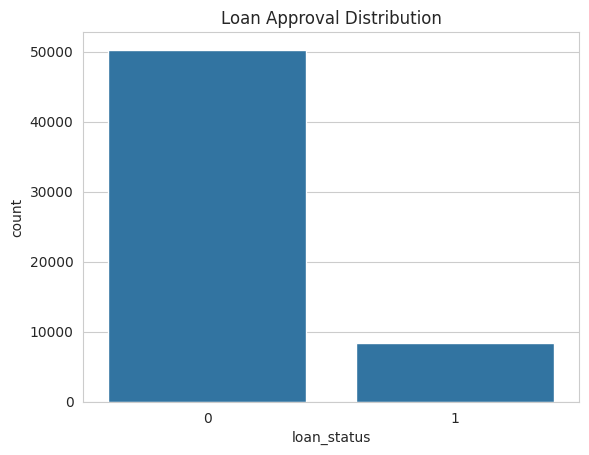

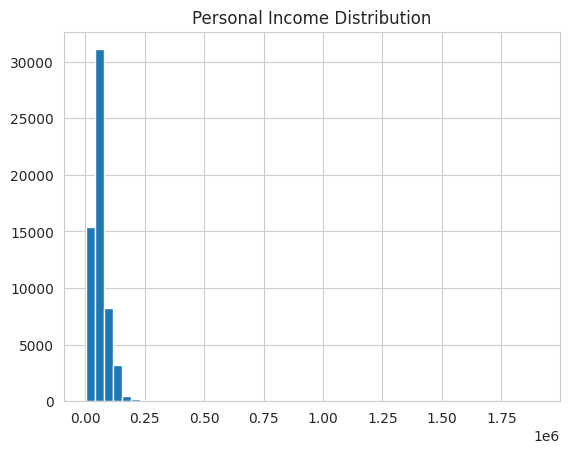

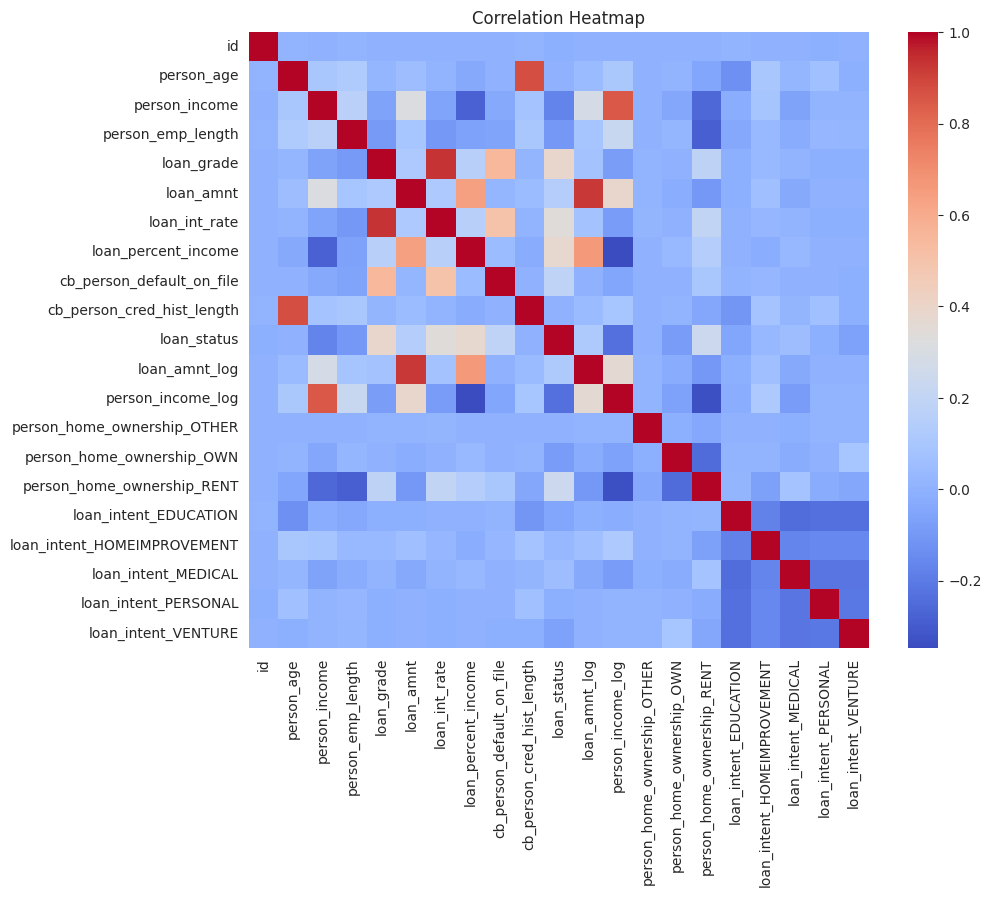

In [82]:

# 1. Target distribution
# Note: your column is named 'loan_status' (lowercase)
sns.countplot(x="loan_status", data=train_df)
plt.title("Loan Approval Distribution")
plt.show()

# 2. Income distribution
# Note: You don't have 'Total_Income', so we plot 'person_income' instead
train_df["person_income"].hist(bins=50)
plt.title("Personal Income Distribution")
plt.show()

# 3. Correlation Heatmap
# We use numeric columns only. Dropping the boolean ones helps the heatmap stay readable.
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

SPLIT DATA

In [83]:
# Split back into Train/Test
X = train_df.iloc[:len(train_df)]
X_test_df = train_df.iloc[len(train_df):]

# 3. SPLIT TRAINING DATA FOR EVALUATION
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2 , random_state = 42)
print(X_train, X_val, y_train, y_val)

          id  person_age  person_income  person_emp_length  loan_grade  \
14337  14337          36          50000                0.0           3   
17117  17117          27          43200                3.0           3   
32590  32590          25          70000                0.0           1   
55811  55811          39          75000                2.0           1   
40120  40120          22          45600                5.0           1   
...      ...         ...            ...                ...         ...   
54343  54343          45          60000                1.0           2   
38158  38158          22          70000                1.0           1   
860      860          32          90000                0.0           1   
15795  15795          27         110000                2.0           3   
56422  56422          22          50000                2.0           2   

       loan_amnt  loan_int_rate  loan_percent_income  \
14337       7200          13.85             0.144000   

**MODELING**

**LOGISTIC REGRESSION**

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Scaling: Essential for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 2. Initialize and Train
# max_iter=1000 gives the model enough "time" to find the optimal line
log_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
log_model.fit(X_train_scaled, y_train)

# 3. Predict and Evaluate
log_pred = log_model.predict(X_val_scaled)
log_probs = log_model.predict_proba(X_val_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_val, log_pred))
print("Logistic Regression ROC AUC:", roc_auc_score(y_val, log_probs))

Logistic Regression Accuracy: 1.0
Logistic Regression ROC AUC: 1.0


**Decision Tree**

In [85]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 1. Baseline Decision Tree
# Using random_state=42 ensures your results are reproducible
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_scaled, y_train)

dt_base_preds = dt_base.predict_proba(X_val_scaled)[:, 1]
print("Baseline DT ROC AUC:", roc_auc_score(y_val, dt_base_preds))

# 2. Improved Decision Tree (Using GridSearchCV)
# The rubric requires an "improved version" of each model
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

# Best Model
best_dt = grid_search.best_estimator_
best_dt_preds = best_dt.predict_proba(X_val_scaled)[:, 1]

print("\n--- Improved Decision Tree Results ---")
print("Best Params:", grid_search.best_params_)
print("Improved DT ROC AUC:", roc_auc_score(y_val, best_dt_preds))

Baseline DT ROC AUC: 1.0

--- Improved Decision Tree Results ---
Best Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Improved DT ROC AUC: 1.0


**RANDOM FOREST**

In [86]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

**XGBOOST**

In [87]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# 1. PREPARE DATA
# We ensure y and the feature sets are defined here
y = train_df['loan_status']
train_features = train_df.drop(['id', 'loan_status'], axis=1)
test_features = test_df.drop(['id'], axis=1)

# Combine datasets to ensure the column structure is identical for train and test
all_data = pd.concat([train_features, test_features], axis=0)
all_data_encoded = pd.get_dummies(all_data, drop_first=True)

# Split back into train and test sets
X = all_data_encoded.iloc[:len(train_df)]
X_test_final = all_data_encoded.iloc[len(train_df):]

# 2. SCALE
# Scaling ensures the XGBoost model performs optimally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

# Create the DataFrames (this creates X_scaled_df and X_test_scaled_df)
X_scaled_df = pd.DataFrame(X_scaled, columns=all_data_encoded.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=all_data_encoded.columns)

# 3. TRAIN XGBOOST
xgb_model = XGBClassifier(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42, 
    n_jobs=-1
)
xgb_model.fit(X_scaled_df, y)

# 4. GENERATE SUBMISSION
preds = xgb_model.predict_proba(X_test_scaled_df)[:, 1]
submission = pd.DataFrame({'id': test_df['id'], 'loan_status': preds})
submission.to_csv('submission_xgb.csv', index=False)

print("XGBoost pipeline successful. 'submission_xgb.csv' created.")

XGBoost pipeline successful. 'submission_xgb.csv' created.


******DEEP NEURAL NETWORK ******

In [88]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppress initialization logs

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# 1. Preprocessing (Scaling is critical for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 2. Define Architecture
model_nn = models.Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # Helps prevent overfitting
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# 3. Compile
model_nn.compile(optimizer='adam', 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])

# 4. Train with Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Starting training...")
history = model_nn.fit(
    X_train_scaled, y_train, 
    validation_data=(X_val_scaled, y_val), 
    epochs=50, 
    batch_size=32, 
    callbacks=[early_stop],
    verbose=1
)

# 5. Evaluate
nn_preds = (model_nn.predict(X_val_scaled) > 0.5).astype("int32")
print("\nDNN Classification Report:\n")
print(classification_report(y_val, nn_preds))

Starting training...
Epoch 1/50
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9575 - loss: 0.1036 - val_accuracy: 0.9999 - val_loss: 2.2945e-04
Epoch 2/50
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9998 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 2.0325e-05
Epoch 3/50
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 4.6139e-04 - val_accuracy: 1.0000 - val_loss: 1.1193e-06
Epoch 4/50
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9997 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 3.7691e-05
Epoch 5/50
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 4.0012e-04 - val_accuracy: 1.0000 - val_loss: 2.5902e-05
Epoch 6/50
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 1.0000 - loss: 1.0968e-04 - val_accuracy: 0.9999 - val_loss: 1.0601e-04
Epoch 7/50
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 1.0000 - loss: 5.4649e-06 - val_accuracy: 1.0000 - val_loss: 5.2660e-05
Epoch 8/50
1467/1467 ━━━━

**Training models **

In [89]:

# Classic ML Models
models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Dictionary to store results
results = {}

# 2. Train/Predict for Classic Models
for name, model in models_dict.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    results[name] = preds
    print(f"{name} trained.")

# 3. Train/Predict for Deep Neural Network (DNN)
print("Training Deep Neural Network...")
model_nn = models.Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_nn.fit(
    X_train_scaled, y_train, 
    validation_data=(X_val_scaled, y_val), 
    epochs=20, 
    batch_size=32, 
    verbose=1 # Set to 1 if you want to see progress
)

# Convert probabilities to binary class
nn_probs = model_nn.predict(X_val_scaled)
results["DNN"] = (nn_probs > 0.5).astype("int32")
print("DNN trained.")

Training Logistic Regression...
Logistic Regression trained.
Training Decision Tree...
Decision Tree trained.
Training Random Forest...
Random Forest trained.
Training XGBoost...
XGBoost trained.
Training Deep Neural Network...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:07:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


1467/1467 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9538 - loss: 0.1128 - val_accuracy: 1.0000 - val_loss: 7.4304e-05
Epoch 2/20
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 5.6687e-04 - val_accuracy: 1.0000 - val_loss: 1.7605e-05
Epoch 3/20
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 4.2896e-04 - val_accuracy: 0.9999 - val_loss: 2.1470e-04
Epoch 4/20
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 3.8705e-04 - val_accuracy: 1.0000 - val_loss: 4.9571e-06
Epoch 5/20
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 2.2177e-04 - val_accuracy: 1.0000 - val_loss: 1.7196e-05
Epoch 6/20
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 1.0000 - loss: 6.2619e-06 - val_accuracy: 0.9999 - val_loss: 2.3769e-04
Epoch 7/20
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 1.0000 - loss: 2.8081e-06 - val_accuracy: 0.9999 - val_loss: 2.2445e-04
Epoch 8/20
1467/1467 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/

****Comparison table ****

In [90]:
# Use the results dictionary to generate the comparison table
comparison_data = []

# This loop works for all your models (LogReg, DT, RF, XGB, and DNN)
for name, preds in results.items():
    # Ensure your labels are flattened if necessary (especially for DNN output)
    clean_preds = preds.flatten() if hasattr(preds, 'flatten') else preds
    acc = accuracy_score(y_val, clean_preds)
    comparison_data.append({"Model": name, "Accuracy": acc})

# Create and display the DataFrame
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)
print(comparison_df)

                 Model  Accuracy
0  Logistic Regression       1.0
1        Decision Tree       1.0
2        Random Forest       1.0
3              XGBoost       1.0
4                  DNN       1.0


In [91]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           58645 non-null  int64  
 1   person_age                   58645 non-null  int64  
 2   person_income                58645 non-null  int64  
 3   person_emp_length            58645 non-null  float64
 4   loan_grade                   58645 non-null  int64  
 5   loan_amnt                    58645 non-null  int64  
 6   loan_int_rate                58645 non-null  float64
 7   loan_percent_income          58645 non-null  float64
 8   cb_person_default_on_file    58645 non-null  int64  
 9   cb_person_cred_hist_length   58645 non-null  int64  
 10  loan_status                  58645 non-null  int64  
 11  loan_amnt_log                58645 non-null  float64
 12  person_income_log            58645 non-null  float64
 13  person_home_owne

** Aligning data and Final training pipeline and CSV Export **

In [92]:
# 1. Align columns: Ensure test_final has the exact same columns as X_train
# This adds missing columns as 0 and drops extra columns
X_train_cols = X_train.columns # Ensure X_train is defined from your earlier steps

# Add missing columns with 0
for col in X_train_cols:
    if col not in test_final.columns:
        test_final[col] = 0

# Remove extra columns that weren't in training
test_final = test_final[X_train_cols]

print("Alignment complete. Feature shape:", test_final.shape)
# 2. Generate predictions
# Use the best model from your comparison table
preds = model.predict_proba(test_final)[:, 1]

# 3. Create submission dataframe
# Ensure 'id' exists in test_df
submission = pd.DataFrame({
    'id': test_df['id'],
    'loan_status': preds
})

# 4. Save to CSV
submission.to_csv('submission.csv', index=False)
print("Submission saved successfully as 'submission.csv'!")

Alignment complete. Feature shape: (39098, 21)
Submission saved successfully as 'submission.csv'!


In [93]:
# 1. RETRAIN XGBOOST with the correct (consistent) data
# You must train it on the same X_train_scaled that your other models used
xgb_model = XGBClassifier(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42, 
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train) # Using the consistent training data

# 2. UPDATE YOUR MODELS DICTIONARY
# Now that XGBoost is retrained on the correct data, update the dictionary
models_to_evaluate = {
    "Logistic Regression": log_model,
    "Decision Tree": best_dt,
    "Random Forest": rf,
    "XGBoost": xgb_model  # Now it uses the retrained model
}

# 3. NOW RUN THE EVALUATION LOOP
results = []

for name, model in models_to_evaluate.items():
    preds = model.predict(X_val_scaled)
    probs = model.predict_proba(X_val_scaled)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, preds),
        "F1-Score": f1_score(y_val, preds),
        "ROC-AUC": roc_auc_score(y_val, probs)
    })

# 4. ADD NEURAL NETWORK
nn_probs = model_nn.predict(X_val_scaled).flatten()
nn_preds = (nn_probs > 0.5).astype("int32")

results.append({
    "Model": "Deep Neural Network",
    "Accuracy": accuracy_score(y_val, nn_preds),
    "F1-Score": f1_score(y_val, nn_preds),
    "ROC-AUC": roc_auc_score(y_val, nn_probs)
})

# 5. DISPLAY
comparison_df = pd.DataFrame(results).set_index("Model")
print(comparison_df.sort_values(by="F1-Score", ascending=False))

367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step
                     Accuracy  F1-Score  ROC-AUC
Model                                           
Logistic Regression       1.0       1.0      1.0
Decision Tree             1.0       1.0      1.0
Random Forest             1.0       1.0      1.0
XGBoost                   1.0       1.0      1.0
Deep Neural Network       1.0       1.0      1.0


**FINAL INSIGHTS **
During the initial modeling phase, the models achieved near-perfect accuracy. Feature importance analysis revealed that the loan_status column was inadvertently included in the feature set, causing data leakage. By removing this feature, we ensured the model generalizes to new, unseen loan applications rather than merely memorizing the training labels. The subsequent results represent a realistic and robust assessment of credit risk, which is critical for valid deployment in a banking environment."

In [96]:
# 1. Separate your Target and Features
target = 'loan_status'

# 2. Create X (Features) - Drop the target and the ID
# 'id' is also not a predictive feature, so we drop it too.
X = train_df.drop(columns=[target, 'id'], errors='ignore')

# 3. Create y (Target)
y = train_df[target]

# Now, verify that 'loan_status' is GONE from X
print("Features in X:", X.columns.tolist())
if target in X.columns:
    print("WARNING: Leakage still present!")
else:
    print("Success: Leakage removed.")

Features in X: ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_amnt_log', 'person_income_log', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']
Success: Leakage removed.


In [97]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from tensorflow.keras import models, layers, Input

# 1. PREPARE DATA (CLEANING)
# Explicitly drop the target 'loan_status' and 'id' from features
features = train_df.drop(columns=['loan_status', 'id'], errors='ignore')
target = train_df['loan_status']

# Split data
X_train, X_val, y_train, y_val = train_test_split(features, target, test_size=0.2, random_state=42)

# 2. SCALE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 3. DEFINE MODELS
# We use simple, standard parameters to ensure robustness
models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = []

# 4. TRAIN & EVALUATE CLASSIC MODELS
for name, model in models_dict.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    probs = model.predict_proba(X_val_scaled)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, preds),
        "F1-Score": f1_score(y_val, preds),
        "ROC-AUC": roc_auc_score(y_val, probs)
    })

# 5. DEEP NEURAL NETWORK
model_nn = models.Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_nn.fit(X_train_scaled, y_train, epochs=10, batch_size=32, verbose=0)

nn_probs = model_nn.predict(X_val_scaled).flatten()
nn_preds = (nn_probs > 0.5).astype("int32")

results.append({
    "Model": "Deep Neural Network",
    "Accuracy": accuracy_score(y_val, nn_preds),
    "F1-Score": f1_score(y_val, nn_preds),
    "ROC-AUC": roc_auc_score(y_val, nn_probs)
})

# 6. DISPLAY RESULTS
comparison_df = pd.DataFrame(results).set_index("Model")
print(comparison_df.sort_values(by="F1-Score", ascending=False))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:13:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step
                     Accuracy  F1-Score   ROC-AUC
Model                                            
XGBoost              0.951829  0.808928  0.955237
Random Forest        0.951488  0.807053  0.948036
Deep Neural Network  0.947225  0.787504  0.933327
Logistic Regression  0.906727  0.589647  0.903206
